# The merger rate seems to increase with increase BH accretion efficiency.

Why is this?

What do I need for this? 3 models with different accretion efficiency and look at different specific models.

Plot their final separation from with the merger region

In [72]:
# Load the three different grids for different accretion efficiencies

# grid locations
grids_path = '/srv/astro/projects/posydon/max/population_synthesis/250825_high_mass/grid_links'

grid_types = ['eddington_limited', 'GRMHD', 'conservative']



import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import cmap
import warnings
from posydon.popsyn.synthetic_population import Population, Rates
from posydon.grids.psygrid import PSyGrid
from posydon.utils.common_functions import convert_metallicity_to_string
from posydon.config import PATH_TO_POSYDON_DATA, PATH_TO_POSYDON
from posydon.utils.common_functions import inspiral_timescale_from_separation
from matplotlib.lines import Line2D

# Suppress warnings about missing ini parameters
warnings.filterwarnings('ignore', message='Missing ini parameter:.*')

# Constants
METALLICITY = 0.01
DPI = 300
DONOR_MASS = 33.8767  # Fixed donor mass in solar masses
HUBBLE_TIME = 13.8e9  # years
MARKER_SIZE = 9
MASS_TOLERANCE = 2.0  # solar masses
CO_TYPE = 'BBH'
SFH_IDENTIFIER = "IllustrisTNG"

inspiral_timescale_from_separation = np.vectorize(inspiral_timescale_from_separation)

plt.style.use(str(Path(PATH_TO_POSYDON) / 'posydon' / 'visualization' / 'posydon.mplstyle'))

# Color schemes
tol_vibrant = cmap.Colormap('tol:vibrant')(np.linspace(0, 1, 7))


In [73]:
def load_grid_data(path, metallicity):
    """
    Load the CO-HMS RLO grid data.
    
    Parameters
    ----------
    path : str or Path
        Path to the grid directory.
    metallicity : float
        Metallicity value.
        
    Returns
    -------
    tuple
        grid, m1_initial, m2_initial, p_initial
    """
    print("  Loading CO-HMS RLO grid...")
    str_met = convert_metallicity_to_string(metallicity)
    CO_HMS_RLO_file = Path(path) / 'CO-HMS_RLO' / f'{str_met}_Zsun.h5'
    grid = PSyGrid(str(CO_HMS_RLO_file))
    print(f"    ✓ Loaded grid from {Path(path).name}")
    
    print("  Parsing initial conditions from grid...")
    m1_initial = np.zeros(len(grid.MESA_dirs))
    p_initial = np.zeros(len(grid.MESA_dirs))
    m2_initial = np.zeros(len(grid.MESA_dirs))  

    for j, i in enumerate(grid.MESA_dirs):
        m2_initial[j] = float(str(i).split('_m2_')[1].split('_')[0])
        m1_initial[j] = float(str(i).split('_m1_')[1].split('_')[0])
        p_initial[j] = float(str(i).split('_days_')[1].split('_')[0])
    print(f"    ✓ Parsed initial conditions")
    
    return grid, m1_initial, m2_initial, p_initial

In [74]:
grid_paths = [Path(grids_path) / grid_type  / 'POSYDON_data' for grid_type in grid_types]
grid_labels = ['Eddington-limited', 'GRMHD', 'Conservative']

In [75]:
PERIOD = 7.2790
BH_MASS = 10.2485

In [76]:
grid_eddington, m1_initial, m2_initial, p_initial = load_grid_data(grid_paths[0], METALLICITY)
# find example model
mask_m1 = np.isclose(m1_initial, DONOR_MASS)
print(np.sum(mask_m1))

mask_P = np.isclose(p_initial, PERIOD)
print(np.sum(mask_P))

mask_m2 = np.isclose(m2_initial, BH_MASS)
print(np.sum(mask_m2))

mask = mask_m1 & mask_P & mask_m2
print(np.sum(mask))

index = np.where(mask)[0][0]
model_eddington = grid_eddington[index]

  Loading CO-HMS RLO grid...
    ✓ Loaded grid from POSYDON_data
  Parsing initial conditions from grid...
    ✓ Parsed initial conditions
489
716
286
1


In [77]:
grid_GRMHD, m1_initial, m2_initial, p_initial = load_grid_data(grid_paths[1], METALLICITY)
# find example model
mask_m1 = np.isclose(m1_initial, DONOR_MASS)
print(np.sum(mask_m1))

mask_P = np.isclose(p_initial, PERIOD)
print(np.sum(mask_P))

mask_m2 = np.isclose(m2_initial, BH_MASS)
print(np.sum(mask_m2))

mask = mask_m1 & mask_P & mask_m2
print(np.sum(mask))

index = np.where(mask)[0][0]
model_GRMHD = grid_GRMHD[index]

  Loading CO-HMS RLO grid...


    ✓ Loaded grid from POSYDON_data
  Parsing initial conditions from grid...
    ✓ Parsed initial conditions
404
594
284
1


In [78]:
grid_conservative, m1_initial, m2_initial, p_initial = load_grid_data(grid_paths[2], METALLICITY)
# find example model
mask_m1 = np.isclose(m1_initial, DONOR_MASS)
print(np.sum(mask_m1))

mask_P = np.isclose(p_initial, PERIOD)
print(np.sum(mask_P))

mask_m2 = np.isclose(m2_initial, BH_MASS)
print(np.sum(mask_m2))

mask = mask_m1 & mask_P & mask_m2
print(np.sum(mask))

index = np.where(mask)[0][0]
model_conservative = grid_conservative[index]

  Loading CO-HMS RLO grid...


    ✓ Loaded grid from POSYDON_data
  Parsing initial conditions from grid...
    ✓ Parsed initial conditions
419
536
263
1


nan years False
nan years False
nan years False


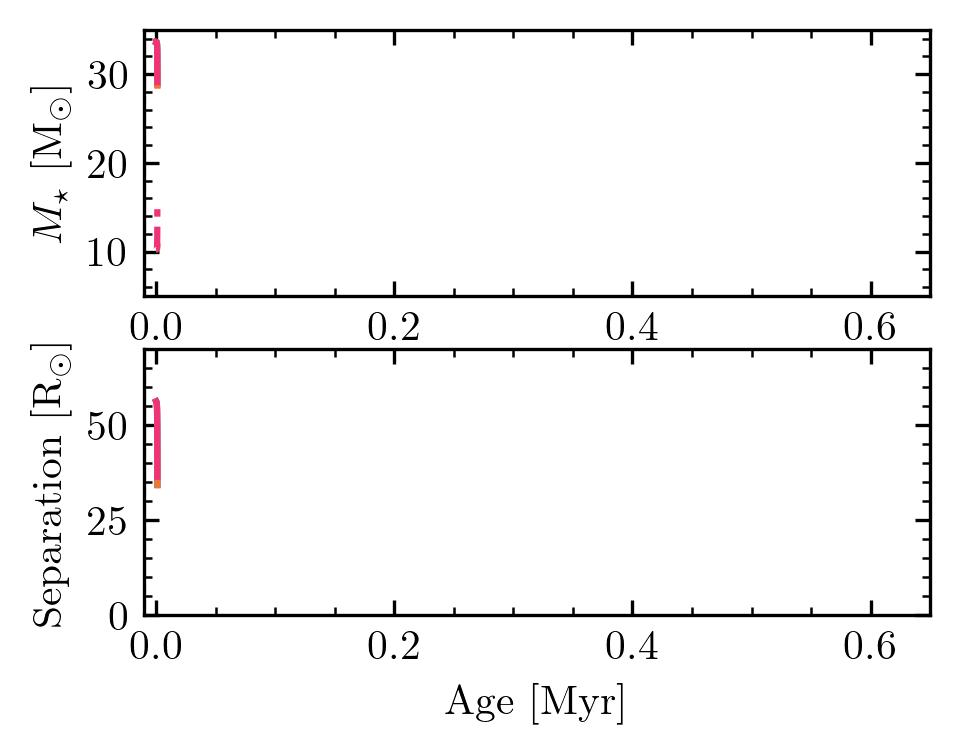

In [79]:
fig, ax = plt.subplots(2, 1, figsize=(3.38, 2.535))

# plot the mass evolution


ax[0].plot(model_eddington.binary_history['age']/1e6, model_eddington.binary_history['star_1_mass'], color=tol_vibrant[0], label='Eddington-limited')
ax[0].plot(model_GRMHD.binary_history['age']/1e6, model_GRMHD.binary_history['star_1_mass'], color=tol_vibrant[3], label='GRMHD')
ax[0].plot(model_conservative.binary_history['age']/1e6, model_conservative.binary_history['star_1_mass'], color=tol_vibrant[5], label='Conservative')

ax[0].plot(model_eddington.binary_history['age']/1e6, model_eddington.binary_history['star_2_mass'], ls='--', color=tol_vibrant[0])
ax[0].plot(model_GRMHD.binary_history['age']/1e6, model_GRMHD.binary_history['star_2_mass'], ls='--', color=tol_vibrant[3])
ax[0].plot(model_conservative.binary_history['age']/1e6, model_conservative.binary_history['star_2_mass'], ls='--', color=tol_vibrant[5])
# and plot the separation/period evolution

#ax[1].plot(model_eddington.binary_history['age'], 10**model_eddington.history1['log_R'])
ax[1].plot(model_eddington.binary_history['age']/1e6, model_eddington.binary_history['binary_separation'], color=tol_vibrant[0], label='Eddington-limited')
ax[1].plot(model_GRMHD.binary_history['age']/1e6, model_GRMHD.binary_history['binary_separation'], color=tol_vibrant[3], label='GRMHD')
ax[1].plot(model_conservative.binary_history['age']/1e6, model_conservative.binary_history['binary_separation'], color=tol_vibrant[5], label='Conservative')

ax[0].set_ylabel('$M_\star$ [M$_\odot$]')
ax[1].set_ylabel('$M_\mathrm{BH}$ [M$_\odot$]')
ax[1].set_xlabel('Age [Myr]')
ax[1].set_ylabel('Separation [R$_\odot$]')

for x in ax:
    x.set_xlim(-0.01, 0.65)
    x.set_xlabel('Age [Myr]')

ax[0].set_ylim(5, 35)
    
ax[1].set_ylim(0,70)

# final masses
merger_times = inspiral_timescale_from_separation(model_eddington.final_values['S1_SN_MODEL_v2_01_mass'],
                                                  model_eddington.final_values['star_2_mass'],
                                                  model_eddington.final_values['binary_separation'],
                                                  0.0)
print(merger_times*1e6, 'years', merger_times*1e6 < HUBBLE_TIME )        

merger_times = inspiral_timescale_from_separation(model_GRMHD.final_values['S1_SN_MODEL_v2_01_mass'],
                                                  model_GRMHD.final_values['star_2_mass'],
                                                  model_GRMHD.final_values['binary_separation'],
                                                  0.0)
print(merger_times*1e6, 'years', merger_times*1e6 < HUBBLE_TIME )

merger_times = inspiral_timescale_from_separation(model_conservative.final_values['S1_SN_MODEL_v2_01_mass'],
                                                  model_conservative.final_values['star_2_mass'],
                                                  model_conservative.final_values['binary_separation'],
                                                  0.0)
print(merger_times*1e6, 'years', merger_times*1e6 < HUBBLE_TIME )                           

This systems becomes wider than it original did and the merger rate no longer allows systems to mege within the Hubble time.

I need an initially tighter systems to try outs

In [63]:
print(np.unique(m2_initial))

[  2.9272   3.5011   4.1874   5.0083   5.9901   7.1643   8.5688  10.2485
  12.2576  14.6605  17.5344  20.9718  25.0829  30.      35.881   42.9149
  51.3276  61.3895  73.4239  87.8174 105.0325 125.6224 150.2485 179.7022
 214.9298 257.0632 307.4561]


In [66]:
PERIOD = 1.7433
BH_MASS = 25.0829
grid_eddington, m1_initial, m2_initial, p_initial = load_grid_data(grid_paths[0], METALLICITY)
# find example model
mask_m1 = np.isclose(m1_initial, DONOR_MASS)
print(np.sum(mask_m1))

mask_P = np.isclose(p_initial, PERIOD)
print(np.sum(mask_P))

mask_m2 = np.isclose(m2_initial, BH_MASS)
print(np.sum(mask_m2))

mask = mask_m1 & mask_P & mask_m2
print(np.sum(mask))

index = np.where(mask)[0][0]
model_eddington = grid_eddington[index]
grid_GRMHD, m1_initial, m2_initial, p_initial = load_grid_data(grid_paths[1], METALLICITY)
# find example model
mask_m1 = np.isclose(m1_initial, DONOR_MASS)
print(np.sum(mask_m1))

mask_P = np.isclose(p_initial, PERIOD)
print(np.sum(mask_P))

mask_m2 = np.isclose(m2_initial, BH_MASS)
print(np.sum(mask_m2))

mask = mask_m1 & mask_P & mask_m2
print(np.sum(mask))

index = np.where(mask)[0][0]
model_GRMHD = grid_GRMHD[index]
grid_conservative, m1_initial, m2_initial, p_initial = load_grid_data(grid_paths[2], METALLICITY)
# find example model
mask_m1 = np.isclose(m1_initial, DONOR_MASS)
print(np.sum(mask_m1))

mask_P = np.isclose(p_initial, PERIOD)
print(np.sum(mask_P))

mask_m2 = np.isclose(m2_initial, BH_MASS)
print(np.sum(mask_m2))

mask = mask_m1 & mask_P & mask_m2
print(np.sum(mask))

index = np.where(mask)[0][0]
model_conservative = grid_conservative[index]

  Loading CO-HMS RLO grid...
    ✓ Loaded grid from POSYDON_data
  Parsing initial conditions from grid...
    ✓ Parsed initial conditions
489
637
289
1
  Loading CO-HMS RLO grid...
    ✓ Loaded grid from POSYDON_data
  Parsing initial conditions from grid...
    ✓ Parsed initial conditions
405
469
278
1
  Loading CO-HMS RLO grid...
    ✓ Loaded grid from POSYDON_data
  Parsing initial conditions from grid...
    ✓ Parsed initial conditions
405
469
265
1


19304804530.53587 years False
15083121558.675055 years False
9871505696.35665 years True


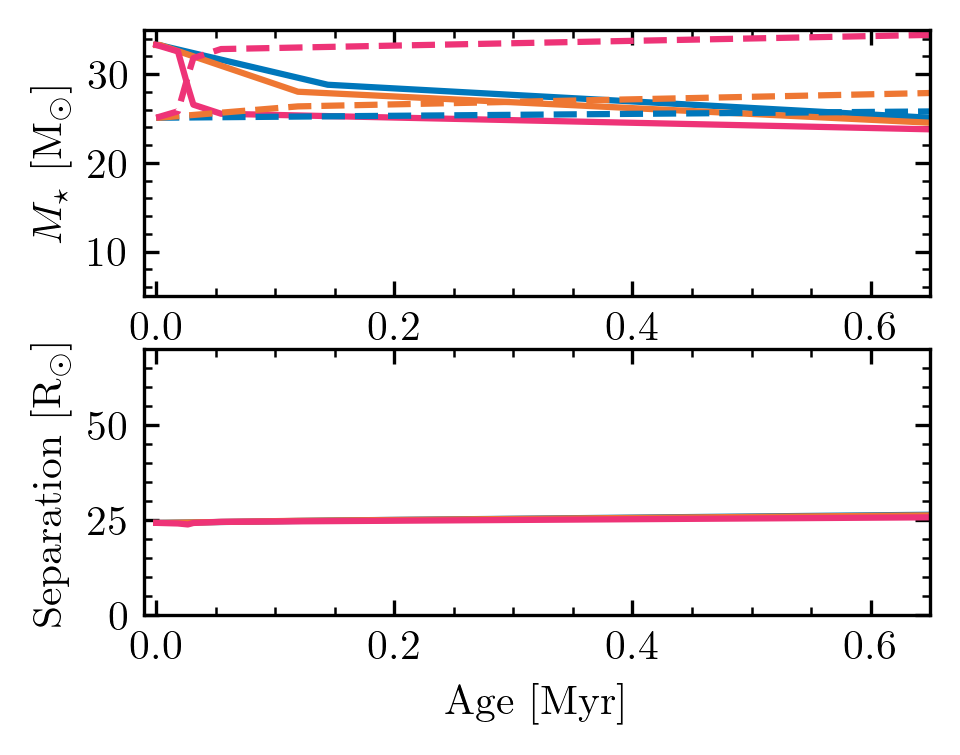

In [67]:
fig, ax = plt.subplots(2, 1, figsize=(3.38, 2.535))

# plot the mass evolution


ax[0].plot(model_eddington.binary_history['age']/1e6, model_eddington.binary_history['star_1_mass'], color=tol_vibrant[0], label='Eddington-limited')
ax[0].plot(model_GRMHD.binary_history['age']/1e6, model_GRMHD.binary_history['star_1_mass'], color=tol_vibrant[3], label='GRMHD')
ax[0].plot(model_conservative.binary_history['age']/1e6, model_conservative.binary_history['star_1_mass'], color=tol_vibrant[5], label='Conservative')

ax[0].plot(model_eddington.binary_history['age']/1e6, model_eddington.binary_history['star_2_mass'], ls='--', color=tol_vibrant[0])
ax[0].plot(model_GRMHD.binary_history['age']/1e6, model_GRMHD.binary_history['star_2_mass'], ls='--', color=tol_vibrant[3])
ax[0].plot(model_conservative.binary_history['age']/1e6, model_conservative.binary_history['star_2_mass'], ls='--', color=tol_vibrant[5])
# and plot the separation/period evolution

#ax[1].plot(model_eddington.binary_history['age'], 10**model_eddington.history1['log_R'])
ax[1].plot(model_eddington.binary_history['age']/1e6, model_eddington.binary_history['binary_separation'], color=tol_vibrant[0], label='Eddington-limited')
ax[1].plot(model_GRMHD.binary_history['age']/1e6, model_GRMHD.binary_history['binary_separation'], color=tol_vibrant[3], label='GRMHD')
ax[1].plot(model_conservative.binary_history['age']/1e6, model_conservative.binary_history['binary_separation'], color=tol_vibrant[5], label='Conservative')

ax[0].set_ylabel('$M_\star$ [M$_\odot$]')
ax[1].set_ylabel('$M_\mathrm{BH}$ [M$_\odot$]')
ax[1].set_xlabel('Age [Myr]')
ax[1].set_ylabel('Separation [R$_\odot$]')

for x in ax:
    x.set_xlim(-0.01, 0.65)
    x.set_xlabel('Age [Myr]')

ax[0].set_ylim(5, 35)
    
ax[1].set_ylim(0,70)

# final masses
merger_times = inspiral_timescale_from_separation(model_eddington.final_values['S1_SN_MODEL_v2_01_mass'],
                                                  model_eddington.final_values['star_2_mass'],
                                                  model_eddington.final_values['binary_separation'],
                                                  0.0)
print(merger_times*1e6, 'years', merger_times*1e6 < HUBBLE_TIME )        

merger_times = inspiral_timescale_from_separation(model_GRMHD.final_values['S1_SN_MODEL_v2_01_mass'],
                                                  model_GRMHD.final_values['star_2_mass'],
                                                  model_GRMHD.final_values['binary_separation'],
                                                  0.0)
print(merger_times*1e6, 'years', merger_times*1e6 < HUBBLE_TIME )

merger_times = inspiral_timescale_from_separation(model_conservative.final_values['S1_SN_MODEL_v2_01_mass'],
                                                  model_conservative.final_values['star_2_mass'],
                                                  model_conservative.final_values['binary_separation'],
                                                  0.0)
print(merger_times*1e6, 'years', merger_times*1e6 < HUBBLE_TIME )                           

In [68]:
print(np.unique(m2_initial))

[  2.9272   3.5011   4.1874   5.0083   5.9901   7.1643   8.5688  10.2485
  12.2576  14.6605  17.5344  20.9718  25.0829  30.      35.881   42.9149
  51.3276  61.3895  73.4239  87.8174 105.0325 125.6224 150.2485 179.7022
 214.9298 257.0632 307.4561]


  Loading CO-HMS RLO grid...
    ✓ Loaded grid from POSYDON_data
  Parsing initial conditions from grid...
    ✓ Parsed initial conditions
489
637
289
1
  Loading CO-HMS RLO grid...
    ✓ Loaded grid from POSYDON_data
  Parsing initial conditions from grid...
    ✓ Parsed initial conditions
405
469
278
1
  Loading CO-HMS RLO grid...
    ✓ Loaded grid from POSYDON_data
  Parsing initial conditions from grid...
    ✓ Parsed initial conditions
405
469
265
1
19304804530.53587 years False
15083121558.675055 years False
9871505696.35665 years True


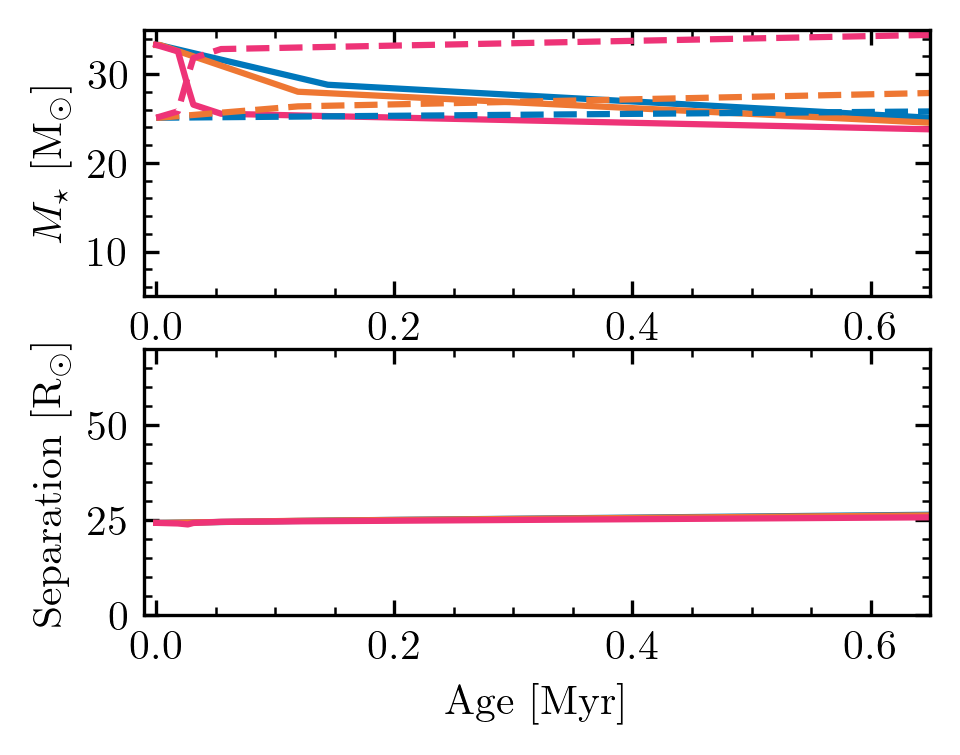

In [71]:
PERIOD = 1.7433
BH_MASS = 25.0829
grid_eddington, m1_initial, m2_initial, p_initial = load_grid_data(grid_paths[0], METALLICITY)
# find example model
mask_m1 = np.isclose(m1_initial, DONOR_MASS)
print(np.sum(mask_m1))

mask_P = np.isclose(p_initial, PERIOD)
print(np.sum(mask_P))

mask_m2 = np.isclose(m2_initial, BH_MASS)
print(np.sum(mask_m2))

mask = mask_m1 & mask_P & mask_m2
print(np.sum(mask))

index = np.where(mask)[0][0]
model_eddington = grid_eddington[index]
grid_GRMHD, m1_initial, m2_initial, p_initial = load_grid_data(grid_paths[1], METALLICITY)
# find example model
mask_m1 = np.isclose(m1_initial, DONOR_MASS)
print(np.sum(mask_m1))

mask_P = np.isclose(p_initial, PERIOD)
print(np.sum(mask_P))

mask_m2 = np.isclose(m2_initial, BH_MASS)
print(np.sum(mask_m2))

mask = mask_m1 & mask_P & mask_m2
print(np.sum(mask))

index = np.where(mask)[0][0]
model_GRMHD = grid_GRMHD[index]
grid_conservative, m1_initial, m2_initial, p_initial = load_grid_data(grid_paths[2], METALLICITY)
# find example model
mask_m1 = np.isclose(m1_initial, DONOR_MASS)
print(np.sum(mask_m1))

mask_P = np.isclose(p_initial, PERIOD)
print(np.sum(mask_P))

mask_m2 = np.isclose(m2_initial, BH_MASS)
print(np.sum(mask_m2))

mask = mask_m1 & mask_P & mask_m2
print(np.sum(mask))

index = np.where(mask)[0][0]
model_conservative = grid_conservative[index]
fig, ax = plt.subplots(2, 1, figsize=(3.38, 2.535))

# plot the mass evolution


ax[0].plot(model_eddington.binary_history['age']/1e6, model_eddington.binary_history['star_1_mass'], color=tol_vibrant[0], label='Eddington-limited')
ax[0].plot(model_GRMHD.binary_history['age']/1e6, model_GRMHD.binary_history['star_1_mass'], color=tol_vibrant[3], label='GRMHD')
ax[0].plot(model_conservative.binary_history['age']/1e6, model_conservative.binary_history['star_1_mass'], color=tol_vibrant[5], label='Conservative')

ax[0].plot(model_eddington.binary_history['age']/1e6, model_eddington.binary_history['star_2_mass'], ls='--', color=tol_vibrant[0])
ax[0].plot(model_GRMHD.binary_history['age']/1e6, model_GRMHD.binary_history['star_2_mass'], ls='--', color=tol_vibrant[3])
ax[0].plot(model_conservative.binary_history['age']/1e6, model_conservative.binary_history['star_2_mass'], ls='--', color=tol_vibrant[5])
# and plot the separation/period evolution

#ax[1].plot(model_eddington.binary_history['age'], 10**model_eddington.history1['log_R'])
ax[1].plot(model_eddington.binary_history['age']/1e6, model_eddington.binary_history['binary_separation'], color=tol_vibrant[0], label='Eddington-limited')
ax[1].plot(model_GRMHD.binary_history['age']/1e6, model_GRMHD.binary_history['binary_separation'], color=tol_vibrant[3], label='GRMHD')
ax[1].plot(model_conservative.binary_history['age']/1e6, model_conservative.binary_history['binary_separation'], color=tol_vibrant[5], label='Conservative')

ax[0].set_ylabel('$M_\star$ [M$_\odot$]')
ax[1].set_ylabel('$M_\mathrm{BH}$ [M$_\odot$]')
ax[1].set_xlabel('Age [Myr]')
ax[1].set_ylabel('Separation [R$_\odot$]')

for x in ax:
    x.set_xlim(-0.01, 0.65)
    x.set_xlabel('Age [Myr]')

ax[0].set_ylim(5, 35)
    
ax[1].set_ylim(0,70)

# final masses
merger_times = inspiral_timescale_from_separation(model_eddington.final_values['S1_SN_MODEL_v2_01_mass'],
                                                  model_eddington.final_values['star_2_mass'],
                                                  model_eddington.final_values['binary_separation'],
                                                  0.0)
print(merger_times*1e6, 'years', merger_times*1e6 < HUBBLE_TIME )        

merger_times = inspiral_timescale_from_separation(model_GRMHD.final_values['S1_SN_MODEL_v2_01_mass'],
                                                  model_GRMHD.final_values['star_2_mass'],
                                                  model_GRMHD.final_values['binary_separation'],
                                                  0.0)
print(merger_times*1e6, 'years', merger_times*1e6 < HUBBLE_TIME )

merger_times = inspiral_timescale_from_separation(model_conservative.final_values['S1_SN_MODEL_v2_01_mass'],
                                                  model_conservative.final_values['star_2_mass'],
                                                  model_conservative.final_values['binary_separation'],
                                                  0.0)
print(merger_times*1e6, 'years', merger_times*1e6 < HUBBLE_TIME )                           